In [22]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize


In [23]:
# === Parameters ===
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
BASE_DIR = Path.cwd()
TEST_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "test"

# === Data Generators ===
# Custom model has Rescaling(1./255) built-in, so no preprocessing function needed
test_datagen_custom = ImageDataGenerator(rescale=1.0 / 255)

test_generator_custom = test_datagen_custom.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

# VGG16 preprocessing
test_datagen_vgg16 = ImageDataGenerator(preprocessing_function=preprocess_vgg16)
test_generator_vgg16 = test_datagen_vgg16.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

# MobileNetV2 preprocessing
test_datagen_mobilenet = ImageDataGenerator(preprocessing_function=preprocess_mobilenetv2)
test_generator_mobilenet = test_datagen_mobilenet.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

class_names = list(test_generator_custom.class_indices.keys())


Found 2627 images belonging to 10 classes.
Found 2627 images belonging to 10 classes.
Found 2627 images belonging to 10 classes.


In [24]:
# === Load Models ===
print("Cargando modelo VGG16...")
model_vgg16 = load_model("mejor_modelo_VGG16.keras")
print("Cargando modelo Custom...")
model_custom = load_model("mejor_modelo_CM.keras")

print("Cargando modelo MobileNetV2...")
model_mobilenet = load_model("mejor_modelo_MBNet.keras")



Cargando modelo VGG16...
Cargando modelo Custom...
Cargando modelo MobileNetV2...


In [25]:
model_vgg16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_mobilenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [26]:
# === Evaluate Models ===
print("\nEvaluando modelo Custom...")
loss_custom, acc_custom = model_custom.evaluate(test_generator_custom, verbose=1)

print("\nEvaluando modelo VGG16...")
loss_vgg16, acc_vgg16 = model_vgg16.evaluate(test_generator_vgg16, verbose=1)

print("\nEvaluando modelo MobileNetV2...")
loss_mobilenet, acc_mobilenet = model_mobilenet.evaluate(test_generator_mobilenet, verbose=1)

print("\n=== Resultados de Evaluación en Test ===")
print(f"Custom      - Accuracy: {acc_custom:.4f}, Loss: {loss_custom:.4f}")
print(f"VGG16       - Accuracy: {acc_vgg16:.4f}, Loss: {loss_vgg16:.4f}")
print(f"MobileNetV2       - Accuracy: {acc_mobilenet:.4f}, Loss: {loss_mobilenet:.4f}")


Evaluando modelo Custom...
83/83 [==============================] - 9s 105ms/step - loss: 0.8774 - accuracy: 0.7168

Evaluando modelo VGG16...
83/83 [==============================] - 27s 313ms/step - loss: 0.1417 - accuracy: 0.9612

Evaluando modelo MobileNetV2...
83/83 [==============================] - 7s 75ms/step - loss: 0.1414 - accuracy: 0.9558

=== Resultados de Evaluación en Test ===
Custom      - Accuracy: 0.7168, Loss: 0.8774
VGG16       - Accuracy: 0.9612, Loss: 0.1417
MobileNetV2       - Accuracy: 0.9558, Loss: 0.1414


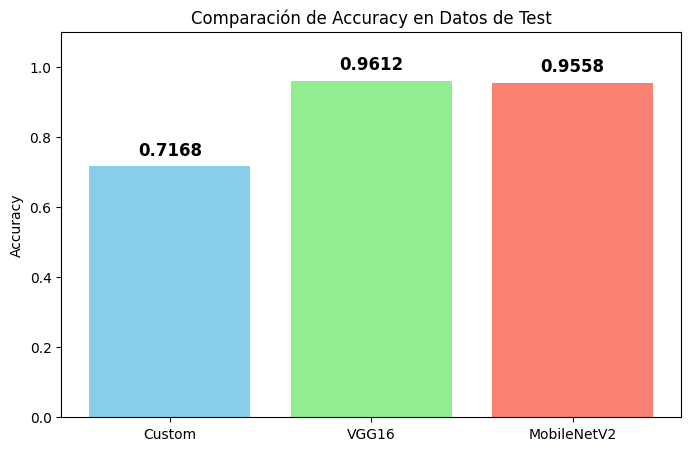

In [27]:
# === Graph Accuracy Comparison ===
models = ['Custom', 'VGG16', 'MobileNetV2']
accuracies = [acc_custom, acc_vgg16, acc_mobilenet]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1.1)
plt.title('Comparación de Accuracy en Datos de Test')
plt.ylabel('Accuracy')

# Añadir etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')




Evaluando Custom Model...
83/83 [==============================] - 6s 66ms/step


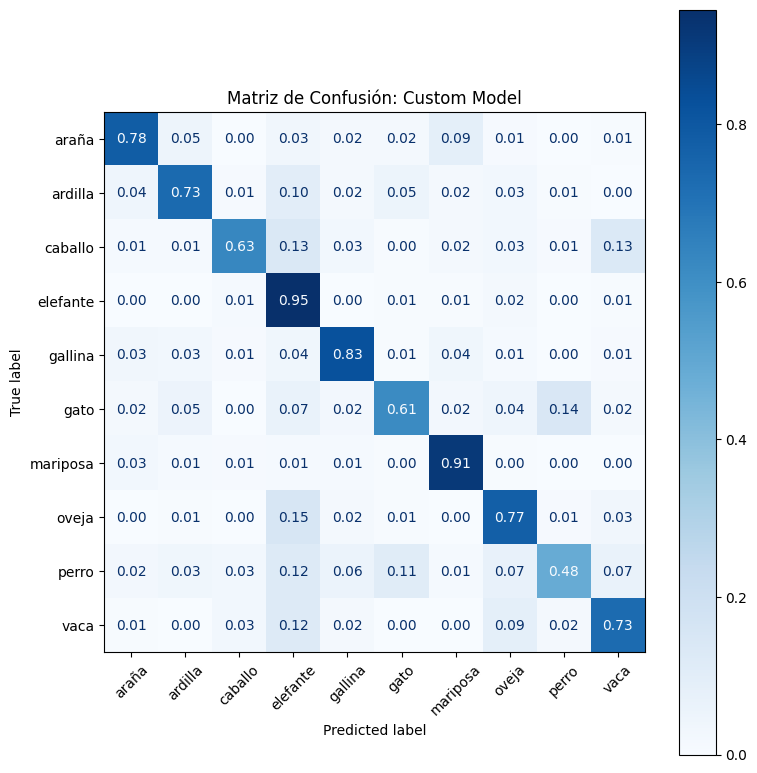


Classification Report: Custom Model

              precision    recall  f1-score   support

       araña       0.90      0.78      0.83       483
     ardilla       0.68      0.73      0.71       187
     caballo       0.86      0.63      0.73       263
    elefante       0.41      0.95      0.57       146
     gallina       0.81      0.83      0.82       311
        gato       0.58      0.61      0.59       168
    mariposa       0.73      0.91      0.81       212
       oveja       0.63      0.77      0.70       182
       perro       0.87      0.48      0.62       487
        vaca       0.63      0.73      0.67       188

    accuracy                           0.72      2627
   macro avg       0.71      0.74      0.70      2627
weighted avg       0.76      0.72      0.72      2627



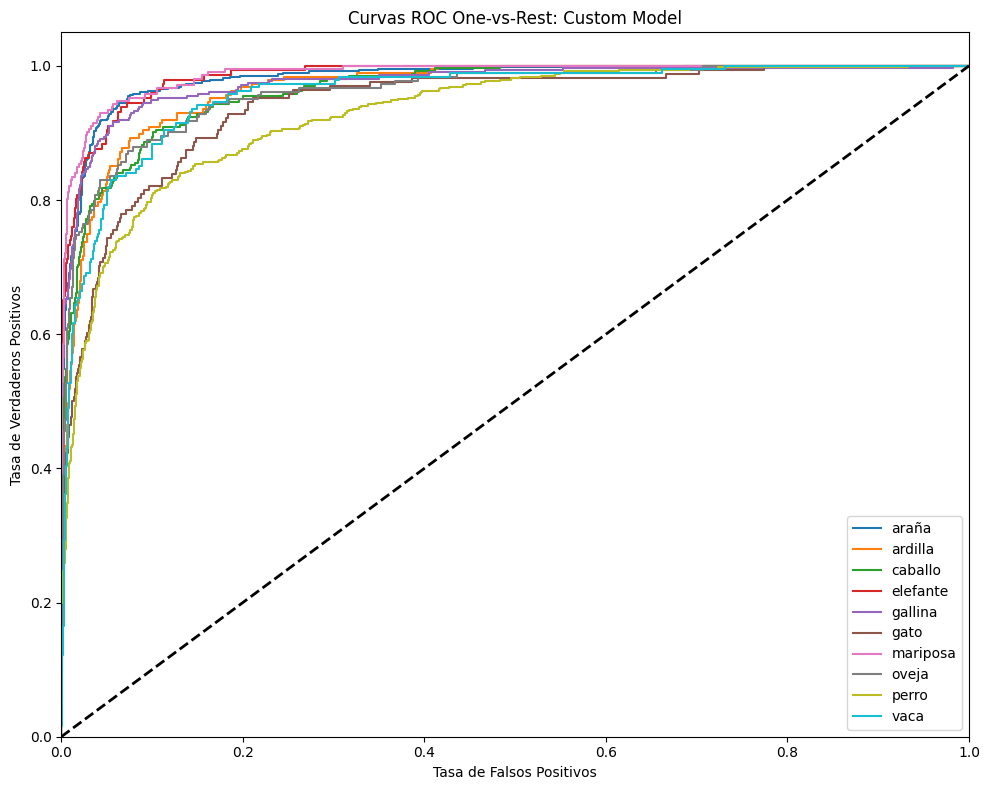


Resumen de métricas:
Model               : Custom Model
Accuracy            : 0.7168
Precision Macro     : 0.7084
Recall Macro        : 0.7423
F1 Macro            : 0.7045
Specificity         : 0.9690
ROC-AUC             : 0.9653

Evaluando VGG16...
83/83 [==============================] - 24s 291ms/step


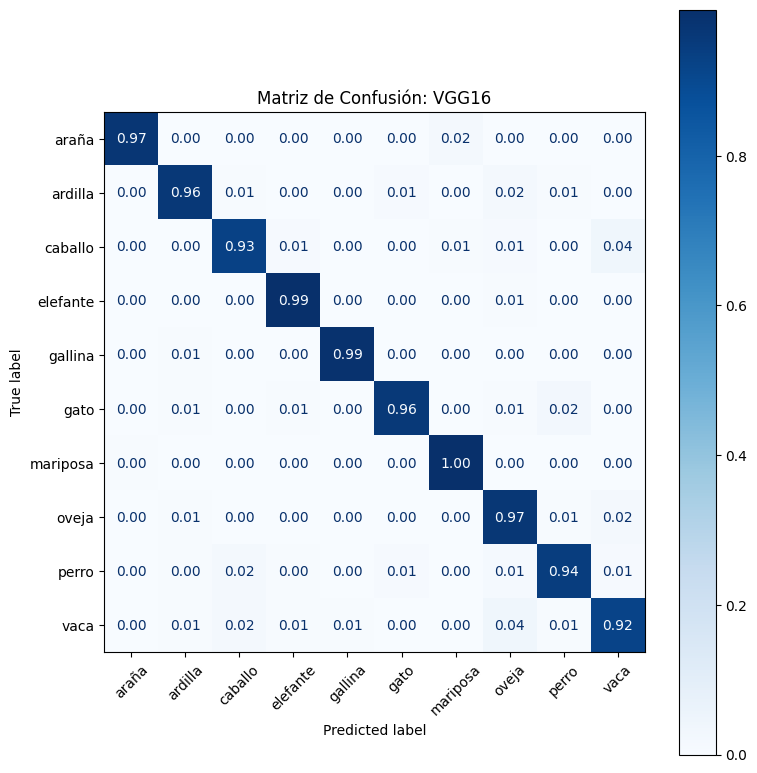


Classification Report: VGG16

              precision    recall  f1-score   support

       araña       1.00      0.97      0.98       483
     ardilla       0.96      0.96      0.96       187
     caballo       0.95      0.93      0.94       263
    elefante       0.95      0.99      0.97       146
     gallina       0.99      0.99      0.99       311
        gato       0.95      0.96      0.96       168
    mariposa       0.94      1.00      0.97       212
       oveja       0.89      0.97      0.93       182
       perro       0.98      0.94      0.96       487
        vaca       0.90      0.92      0.91       188

    accuracy                           0.96      2627
   macro avg       0.95      0.96      0.96      2627
weighted avg       0.96      0.96      0.96      2627



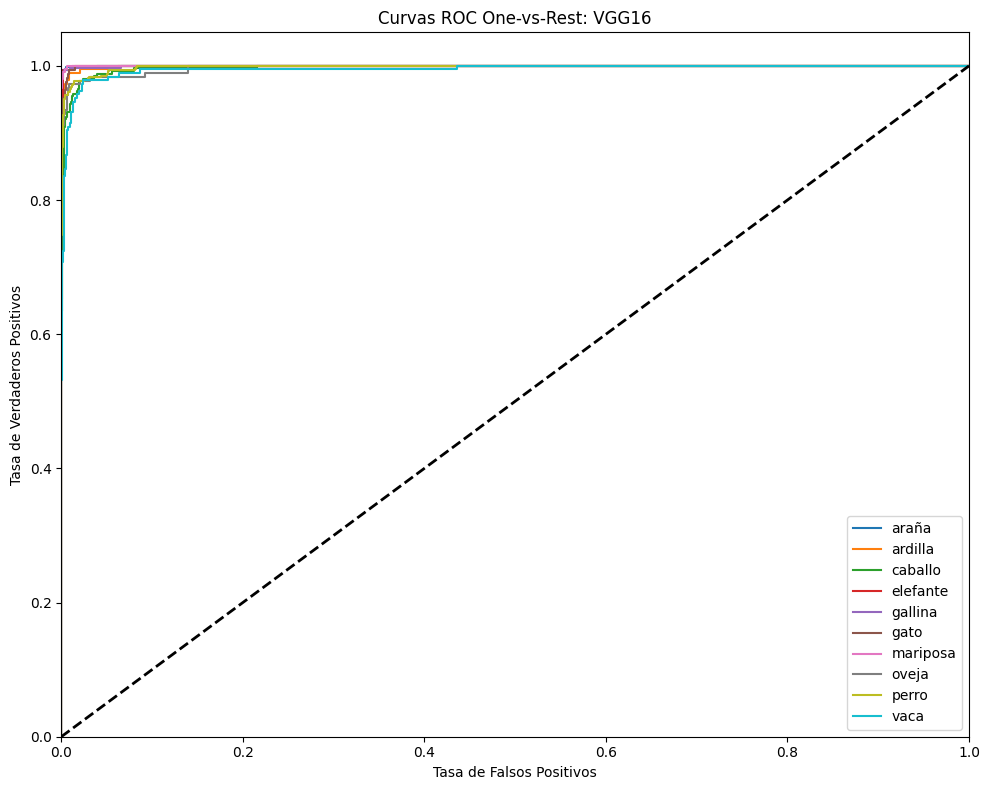


Resumen de métricas:
Model               : VGG16
Accuracy            : 0.9612
Precision Macro     : 0.9512
Recall Macro        : 0.9625
F1 Macro            : 0.9565
Specificity         : 0.9958
ROC-AUC             : 0.9985

Evaluando MobileNetV2...
83/83 [==============================] - 7s 77ms/step


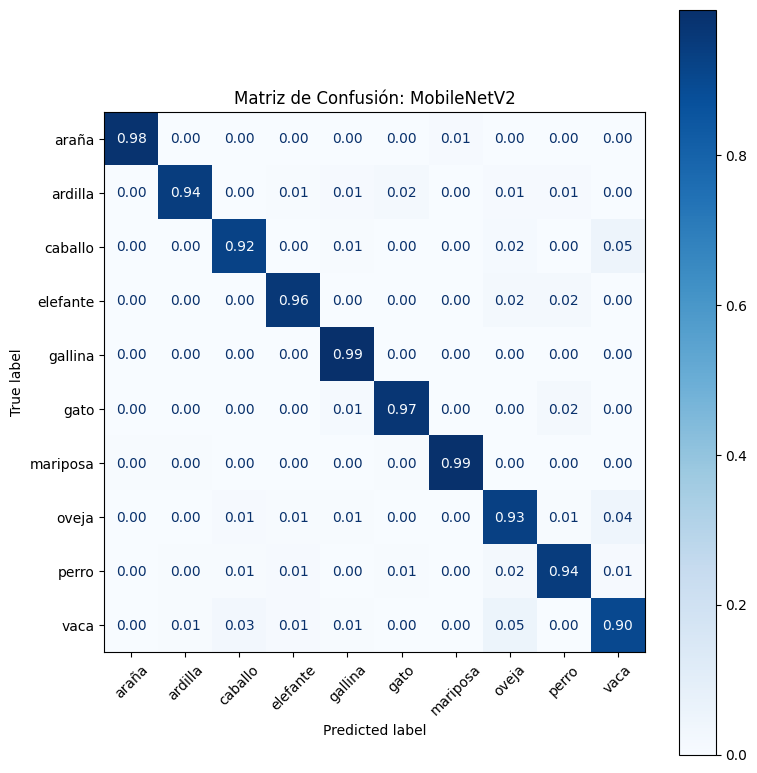


Classification Report: MobileNetV2

              precision    recall  f1-score   support

       araña       1.00      0.98      0.99       483
     ardilla       0.97      0.94      0.96       187
     caballo       0.96      0.92      0.94       263
    elefante       0.93      0.96      0.95       146
     gallina       0.97      0.99      0.98       311
        gato       0.95      0.97      0.96       168
    mariposa       0.97      0.99      0.98       212
       oveja       0.86      0.93      0.89       182
       perro       0.98      0.94      0.96       487
        vaca       0.87      0.90      0.88       188

    accuracy                           0.96      2627
   macro avg       0.95      0.95      0.95      2627
weighted avg       0.96      0.96      0.96      2627



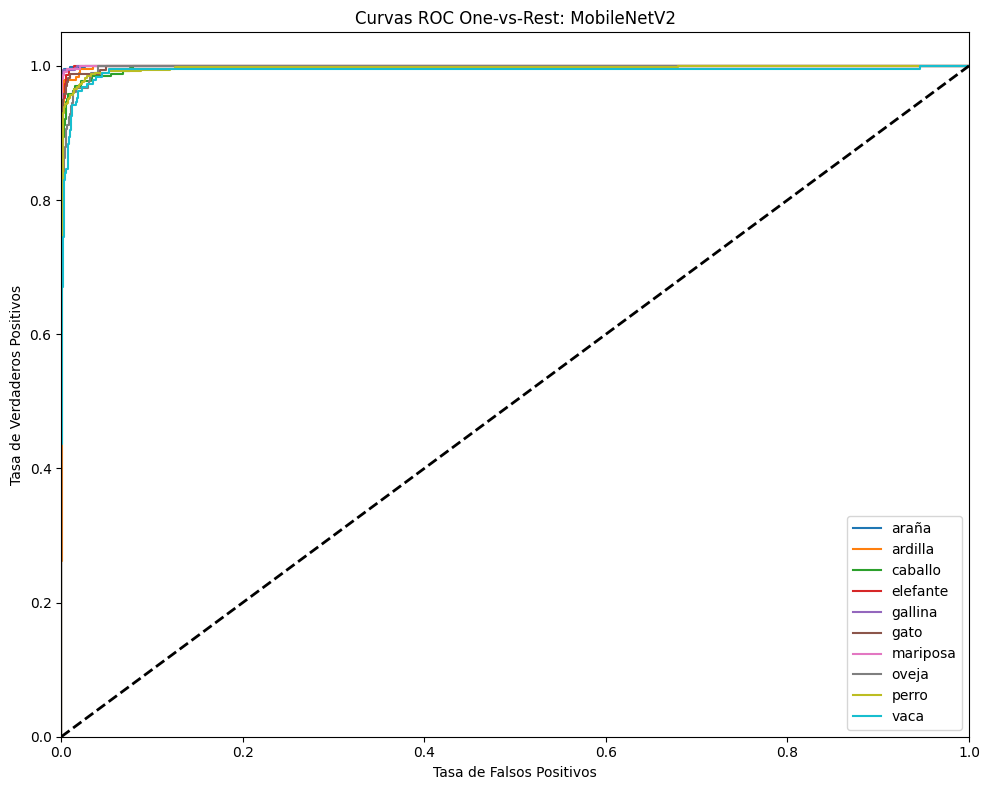


Resumen de métricas:
Model               : MobileNetV2
Accuracy            : 0.9558
Precision Macro     : 0.9452
Recall Macro        : 0.9523
F1 Macro            : 0.9484
Specificity         : 0.9952
ROC-AUC             : 0.9982


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Specificity,ROC-AUC
0,Custom Model,0.7168,0.7084,0.7423,0.7045,0.9690,0.9653
1,VGG16,0.9612,0.9512,0.9625,0.9565,0.9958,0.9985
2,MobileNetV2,0.9558,0.9452,0.9523,0.9484,0.9952,0.9982


In [30]:
# ============================================================
# Evaluación Avanzada y Matrices de Confusión
# ============================================================

def evaluate_model_advanced(model, generator, title, class_names):
    print(f"\n{'='*50}")
    print(f"Evaluando {title}...")
    print(f"{'='*50}")

    generator.reset()

    preds = model.predict(generator, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes

    # ============================================================
    # 1. Matriz de confusión normalizada (para visualización)
    # ============================================================
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(
        cmap=plt.cm.Blues,
        ax=ax,
        xticks_rotation=45,
        values_format=".2f"
    )

    plt.title(f"Matriz de Confusión: {title}")
    plt.tight_layout()
    plt.show()

    # ============================================================
    # 2. Matriz de confusión cruda (para cálculos)
    # ============================================================
    cm_raw = confusion_matrix(y_true, y_pred)

    # ============================================================
    # Classification Report
    # ============================================================
    print(f"\nClassification Report: {title}\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    metrics = {"Model": title}

    # Accuracy
    metrics["Accuracy"] = accuracy_score(y_true, y_pred)

    # Precision Macro
    metrics["Precision Macro"] = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    # Recall Macro
    metrics["Recall Macro"] = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    # F1 Macro
    metrics["F1 Macro"] = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    # ============================================================
    # Specificity Macro
    # ============================================================
    specificity_list = []

    for i in range(len(class_names)):

        tn = np.sum(np.delete(np.delete(cm_raw, i, axis=0), i, axis=1))
        fp = np.sum(cm_raw[:, i]) - cm_raw[i, i]

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        specificity_list.append(specificity)

    metrics["Specificity"] = np.mean(specificity_list)

    # ============================================================
    # ROC-AUC
    # ============================================================
    try:

        y_true_bin = label_binarize(
            y_true,
            classes=range(len(class_names))
        )

        metrics["ROC-AUC"] = roc_auc_score(
            y_true_bin,
            preds,
            multi_class="ovr",
            average="macro"
        )

        plt.figure(figsize=(10, 8))

        for i in range(len(class_names)):
            fpr, tpr, _ = roc_curve(
                y_true_bin[:, i],
                preds[:, i]
            )

            plt.plot(fpr, tpr, label=class_names[i])

        plt.plot([0, 1], [0, 1], "k--", lw=2)

        plt.xlim([0, 1])
        plt.ylim([0, 1.05])

        plt.xlabel("Tasa de Falsos Positivos")
        plt.ylabel("Tasa de Verdaderos Positivos")
        plt.title(f"Curvas ROC One-vs-Rest: {title}")

        plt.legend(loc="lower right")

        plt.tight_layout()
        plt.show()

    except Exception:
        metrics["ROC-AUC"] = np.nan
        print(f"No se pudo calcular ROC-AUC para {title}.")

    # ============================================================
    # Resumen de métricas
    # ============================================================
    print("\nResumen de métricas:")

    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key:20}: {value:.4f}")
        else:
            print(f"{key:20}: {value}")

    return metrics


# ============================================================
# Evaluar modelos
# ============================================================

results = []

results.append(
    evaluate_model_advanced(
        model_custom,
        test_generator_custom,
        "Custom Model",
        class_names
    )
)

results.append(
    evaluate_model_advanced(
        model_vgg16,
        test_generator_vgg16,
        "VGG16",
        class_names
    )
)

results.append(
    evaluate_model_advanced(
        model_mobilenet,
        test_generator_mobilenet,
        "MobileNetV2",
        class_names
    )
)

# ============================================================
# Tabla comparativa
# ============================================================

results_df = pd.DataFrame(results)

display(results_df.round(4))

In [20]:
# === Comparación Consolidada ===

df_results = pd.DataFrame(results)

# Renombrar columnas según lo solicitado
df_results = df_results.rename(columns={'Model': 'Modelo'})

print("\nTabla Comparativa de Modelos:")
display(df_results)


Tabla Comparativa de Modelos:


,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro,Specificity,ROC-AUC
0,Custom Model,0.716787,0.708365,0.742332,0.704500,0.971370,0.965286
1,VGG16,0.961172,0.951168,0.962499,0.956469,0.995833,0.998544
2,MobileNetV2,0.955843,0.945205,0.952332,0.948444,0.994704,0.998188
